# Clase 12: Aprendizaje de Máquina (No Supervisado)


Construcción de algoritmos que aprenden una función de mapeo $$f(x)$$ a partir de datos $$x$$ para realizar predicciones o descubrir patrones. En la mayoría de casos, se hace a través de *optimización*, que es buscar encontrar la mejor solución posible según una función objetivo.

### Tres enfoques de Machine Learning

**No supervisado (Exploratorio):** Exploración de la estructura intrínseca o de las distribuciones de probabilidad dentro de datos sin etiquetas (*labels*).

**Supervisado (Guiado):** Aprendizaje a partir de datos previamente etiquetados \$$x_i\to y_i.$$ Las etiquetas pueden ser categóricas o continuas (regresión).

**Por refuerzo (Conductual):** Optimización mediante prueba y error utilizando una función de recompensa.

### Metodologías y algoritmos

**No supervisado:** Infiere la densidad de probabilidad subyacente $$P(x)$$ (*density estimation*) o la estructura geométrica latente (*dimensionality reduction*). Algoritmos típicos:

- Kernel Density Estimation (DE)
- K-means (DE, clustering)
- DBSCAN (DE, clustering)
- Gaussian Mixture Models (DE, clustering)
- Principal Component Analysis (DR)
- Locally Linear Embedding (DR)
- UMAP (DR)

Ejemplos:
- Encontrar poblaciones estelares distintas en un cúmulo.
- Detectar agrupamientos de galaxias en grandes surveys.
- Buscar objetos “raros” o anomalías (*outliers*) en catálogos astronómicos.
- Reducir dimensionalidad de espectros o cubos de datos.

**Supervisado:** Mapea entradas hacia objetivos conocidos minimizando una función de pérdida $$L(y, \hat{y}).$$  Algoritmos típicos:
- Regresión lineal
- Regresión logística
- Árboles de decisión
- Random Forest
- Support Vector Machines (SVM)
- Gradient Boosting
- Redes neuronales (NNs)

Ejemplos:
- Clasificación morfológica de galaxias.
- Clasificación automática de curvas de luz para eventos transitorios.
- Estimación de redshifts fotométricos por regresión.


**Por refuerzo:** Aprende secuencias de decisiones que maximizan recompensas futuras a partir de interacción continua con un entorno. Algoritmos típicos:

- Q-Learning
- QNN

Ejemplos:
- Control adaptativo de telescopios.
- Control de sistemas de óptica adaptativa.
- Optimización de observaciones.

[Más información](https://www.emergentmind.com/topics/reinforcement-learning-for-telescope-operations]).

## Scikit-learn (sklearn)

- Biblioteca de *machine learning* para Python. [Documentación](https://scikit-learn.org/stable/index.html).

- Tiene implementaciones de muchos algoritmos supervisados y no supervisados.

- Incluye herramientas para:
  - clasificación,
  - regresión (p. ej. mínimos cuadrados),
  - clustering,
  - reducción de dimensionalidad,
  - validación y selección de modelos.

Citación: Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.


## Glosario

### Hiperparámetros

- Parámetros definidos antes del entrenamiento del modelo.
- Controlan cómo aprende el algoritmo.
- Ejemplos:
  - learning rate,
  - número de grupos (*clusters*),
  - número de dimensiones
  - división de datos de entrenamiento/prueba/validación
  - profundidad de un árbol,
  - bandwidth en KDE.
- Generalmente se ajustan mediante validación cruzada o búsqueda automática.

### Cross-validation

- Técnica de remuestreo para evaluar modelos, estimadores, o hiperparámetros usando subconjuntos distintos de los datos.

- Parte de los datos se excluye temporalmente del ajuste y luego se usa para evaluación.

- El proceso se repite múltiples veces con diferentes particiones.

- Permite estimar desempeño fuera de muestra (validación).

Ejemplo: *k-fold validation*

- Los datos se dividen en \(k\) subconjuntos.
- Se ajusta el modelo con \(k-1\) subconjuntos.
- El restante se usa para evaluación.
- El proceso se repite \(k\) veces.

### Métricas

- Cantidad numérica utilizada para evaluar el desempeño de un modelo o estimador.

- Mide qué tan bien el modelo realiza una tarea específica.

- Se usa para:
  - comparar modelos,
  - seleccionar hiperparámetros,
  - evaluar generalización.

- La métrica depende del tipo de problema:
  - clasificación,
  - regresión,
  - estimación de densidad,
  - clustering.

Ejemplos:

- Accuracy
- F1-score
- Mean Squared Error (MSE)
- \(R^2\)
- Log-likelihood


### Función objetivo

- Función matemática que define qué significa “hacerlo bien”.
- El algoritmo intenta minimizarla o maximizarla.
- La *métrica* es el resultado óptimo de una función objetivo.
- En ML suele medir error entre predicciones y datos reales.
- Ejemplos:
  - error cuadrático,
  - entropía cruzada,
  - likelihood.

### Optimización

- Rama de las matemáticas y computación dedicada a encontrar la mejor solución posible según un criterio definido.

- Consiste en maximizar o minimizar una función objetivo.

- La solución óptima corresponde al conjunto de parámetros que produce el mejor valor de esa función.

- En machine learning, la optimización se usa para ajustar parámetros minimizando funciones de pérdida.

- La mayoría de algoritmos de ML convierten el aprendizaje en un problema de optimización.

- *El aprendizaje busca el resultado de la optimización. La optimización provee muchos métodos posibles para llegar a un máximo/mínimo de una función objetivo.*

### Clustering

- Agrupamiento automático de datos similares sin etiquetas previas.
- Objetivo: encontrar estructuras o poblaciones ocultas.
- Los grupos se forman según similitud o distancia.

### Reducción de dimensionalidad

- Técnicas para representar datos complejos usando menos variables.
- Busca conservar la información más importante.
- Útil para:
  - visualización,
  - eliminar ruido,
  - acelerar cálculos.





## Distribución de Exoplanetas: Kernel Density Estimation (KDE)

- Método no supervisado para estimar la distribución de probabilidad de un conjunto de datos.

- Convierte datos discretos en una función continua y suave de densidad.

- A cada dato se le asigna un “kernel” (usualmente una gaussiana), y la distribución total se obtiene sumando todos los kernels.

- El parámetro más importante es el *bandwidth* *h*:
  - *h* pequeño → distribución muy ruidosa;
  - *h* grande → distribución demasiado suavizada.

- KDE es como un "histograma continuo".

- Describe cómo están distribuidos los datos.

In [1]:
pip install astroquery

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from astropy.units import au, M_jup
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive


columns = [
    'pl_name',    # Exoplanet name
    'pl_bmassj',  # Planetary mass (Jupiter mass)
    'pl_orbsmax',  # Orbital semi-major axis (AU)
    'st_met', # Stellar metallicity
]

table = NasaExoplanetArchive.query_criteria(
    table='pscomppars', # Specify the table name (e.g., 'pscomppars' for composite planet parameters)
    select=','.join(columns),
    where='pl_bmassj is not null and pl_orbsmax is not null and pl_controv_flag = 0',
    order='pl_name ASC' # Order by name y
)

print(f"Found {len(table)} exoplanets with reported mass and semi-major axis.")

mass_values = np.array(table['pl_bmassj'].value)
semimajor_axis_values = np.array(table['pl_orbsmax'].value)
names_values = np.array(table['pl_name'].value)
metal_values = np.array(table['st_met'].value)

Found 5793 exoplanets with reported mass and semi-major axis.


In [3]:
# Ensure data is positive for log scaling and filter out invalid values
valid_indices = (mass_values > 0) & (semimajor_axis_values > 0)
mass_values = mass_values[valid_indices]
semimajor_axis_values = semimajor_axis_values[valid_indices]
names_values= names_values[valid_indices]
metal_values= metal_values[valid_indices]


log_mass = np.log10(mass_values)
log_semimajor_axis = np.log10(semimajor_axis_values)

data = np.vstack([log_mass, log_semimajor_axis]).T

Text(0, 0.5, 'log Mass (Jupiter Masses)')

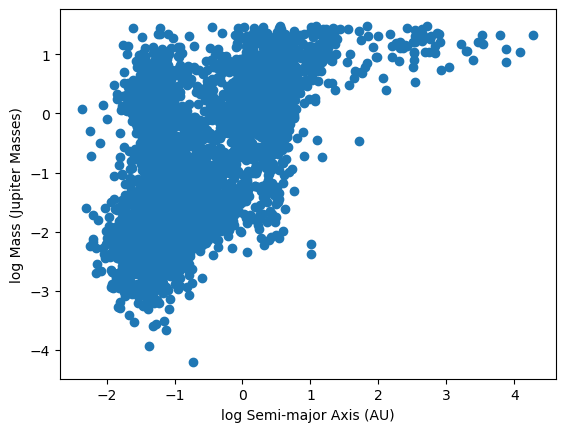

In [4]:
plt.scatter(log_semimajor_axis,log_mass)


plt.xlabel('log Semi-major Axis (AU)')
plt.ylabel('log Mass (Jupiter Masses)')


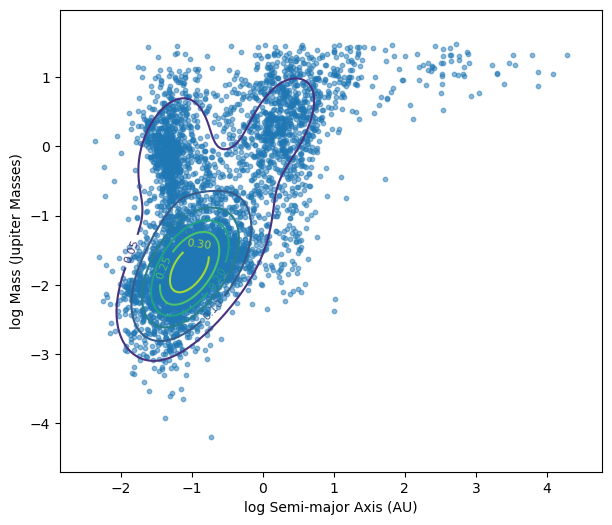

In [5]:
from scipy.stats import gaussian_kde

# Your scatter plot
plt.figure(figsize=(7,6))
plt.scatter(log_semimajor_axis, log_mass, s=10, alpha=0.5)

# Stack the data for KDE
values = np.vstack([log_semimajor_axis, log_mass])

# KDE with bandwidth = 0.5
kde = gaussian_kde(values, bw_method=0.5)

# Create grid
xgrid = np.linspace(log_semimajor_axis.min()-0.5,
                    log_semimajor_axis.max()+0.5, 200)

ygrid = np.linspace(log_mass.min()-0.5,
                    log_mass.max()+0.5, 200)

X, Y = np.meshgrid(xgrid, ygrid)

# Evaluate KDE on the grid
positions = np.vstack([X.ravel(), Y.ravel()])
Z = kde(positions).reshape(X.shape)

# Plot contours
contours = plt.contour(X, Y, Z, levels=6)

# Optional contour labels
plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel('log Semi-major Axis (AU)')
plt.ylabel('log Mass (Jupiter Masses)')

plt.show()

### Ejemplo de validación cruzada: GridSearchCV

- Método automático para buscar los mejores hiperparámetros de un modelo.

- Prueba múltiples combinaciones de hiperparámetros definidas por el usuario.

- Cada combinación se evalúa usando *cross-validation*.

- Selecciona la combinación con mejor desempeño promedio según una métrica (`scoring`). Para KDE, se busca minimizar el log-*likelihood* (verosimilitud),

$$\log L(h) = \log \prod_{i=1}^{n} f(x_i \mid h) = \sum_{i=1}^{n} \log f(x_i \mid h)
$$

Para un kernel gaussiano,

$$f(x_i \mid h) = \frac{1}{N \cdot h} \sum_{j=1}^{N} \frac{1}{\sqrt{2\pi}} \exp\left( -\frac{(x_i - x_j)^2}{2h^2} \right).
$$

Best bandwidth: 0.124


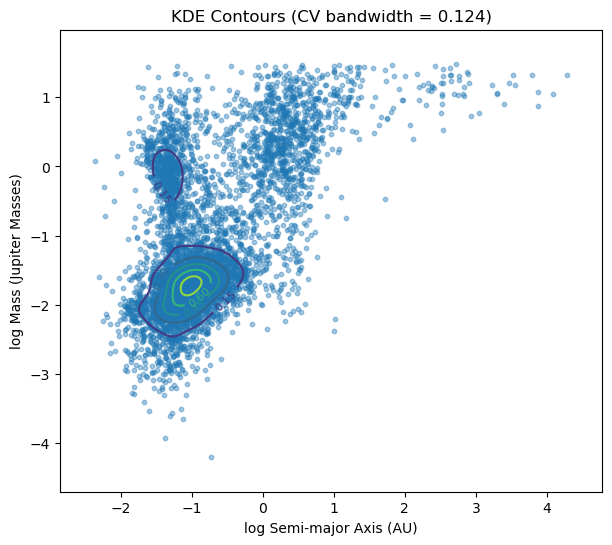

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity

x = np.array(log_semimajor_axis)
y = np.array(log_mass)

data = np.vstack([x, y]).T

# cross-validation hyperparameter space
bandwidths = np.linspace(0.05, 1.5, 40)

grid = GridSearchCV(
    KernelDensity(kernel='gaussian'),
    {'bandwidth': bandwidths},
    cv=5
)

grid.fit(data)

best_bw = grid.best_params_['bandwidth']

print(f"Best bandwidth: {best_bw:.3f}")

# we now use sklearn
kde = KernelDensity(
    bandwidth=best_bw,
    kernel='gaussian'
)

kde.fit(data)

# create a grid for evaluation
xgrid = np.linspace(x.min()-0.5, x.max()+0.5, 200)
ygrid = np.linspace(y.min()-0.5, y.max()+0.5, 200)

X, Y = np.meshgrid(xgrid, ygrid)

grid_points = np.vstack([X.ravel(), Y.ravel()]).T

# Evaluate KDE
log_density = kde.score_samples(grid_points)
Z = np.exp(log_density).reshape(X.shape)

plt.figure(figsize=(7,6))

plt.scatter(x, y, s=10, alpha=0.4)

contours = plt.contour(
    X, Y, Z,
    levels=6
)

plt.clabel(contours, inline=True, fontsize=8)

plt.xlabel('log Semi-major Axis (AU)')
plt.ylabel('log Mass (Jupiter Masses)')

plt.title(f'KDE Contours (CV bandwidth = {best_bw:.3f})')

plt.show()

### Alternativa visual: Seaborn

La librería `seaborn` tiene herramientas de visualización de densidad como `kdeplot` y `distplot`. Pruebe a hacer los plots anteriores con esas herramientas.

## Distribución de Exoplanetas: Gaussian Mixture Models (GMM)

- Modelo probabilístico que representa los datos como una combinación de múltiples distribuciones gaussianas con distintas restricciones sobre la covarianza entre los datos. [Más información](https://scikit-learn.org/stable/auto_examples/mixture/plot_gmm_covariances.html).

- Cada gaussiana describe una posible población o componente dentro de los datos.

- El modelo estima:
  - medias,
  - covarianzas,
  - pesos relativos de cada componente.

- Alternativa: *K-means clustering*.

### Algoritmo optimización: *Expectation-Maximization* (EM)

1. Inicializar parámetros de las gaussianas.
2. Calcular probabilidades de pertenencia de cada punto a cada componente (*Expectation step*).
3. Actualizar parámetros usando esas probabilidades (*Maximization step*).
4. Repetir hasta convergencia.

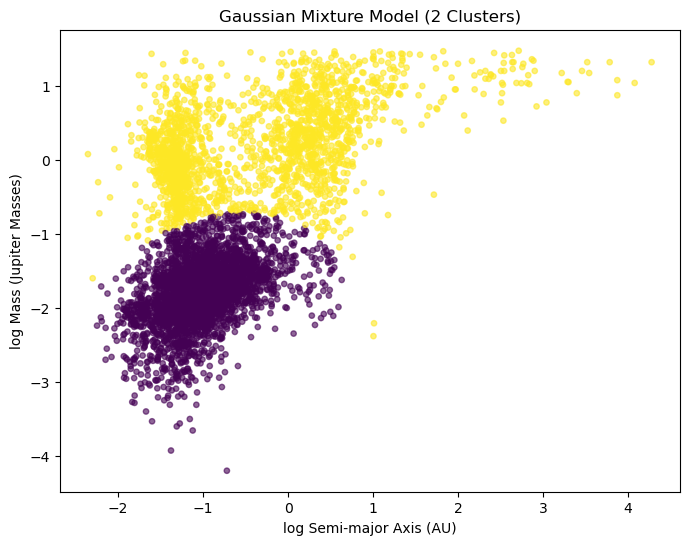


Cluster 0
Mean:
[-1.01373183 -1.77981885]
Covariance:
[[0.16973912 0.07387139]
 [0.07387139 0.1817889 ]]
Weight:
0.6547069917964242

Cluster 1
Mean:
[-0.3553021   0.18458255]
Covariance:
[[1.02745111 0.28104515]
 [0.28104515 0.37062087]]
Weight:
0.3452930082035757


In [7]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=42
)

gmm.fit(data) # fit the data
labels = gmm.predict(data) # assign data to a cluster
means = gmm.means_ # cluster center


plt.figure(figsize=(8,6))

# Scatter colored by cluster
plt.scatter(
    x,
    y,
    c=labels,
    s=15,
    alpha=0.6
)


plt.xlabel('log Semi-major Axis (AU)')
plt.ylabel('log Mass (Jupiter Masses)')

plt.title('Gaussian Mixture Model (2 Clusters)')

plt.show()


for i in range(2):
    print(f"\nCluster {i}")
    print("Mean:")
    print(gmm.means_[i])

    print("Covariance:")
    print(gmm.covariances_[i])

    print("Weight:")
    print(gmm.weights_[i])

Veamos la probabilidad de pertenencia a un cluster para algún planeta aleatorio.

In [8]:
idx = np.random.randint(len(data))

point = data[idx].reshape(1, -1)

probs = gmm.predict_proba(point)[0]

print("\nCluster membership probabilities:")

for i, p in enumerate(probs):
    print(f"Cluster {i}: {p:.4f}")

# Most likely cluster
predicted_cluster = np.argmax(probs)


print(f"\nAssigned cluster: {predicted_cluster}"+" for planet "+names_values[idx])


Cluster membership probabilities:
Cluster 0: 0.9997
Cluster 1: 0.0003

Assigned cluster: 0 for planet Kepler-205 b


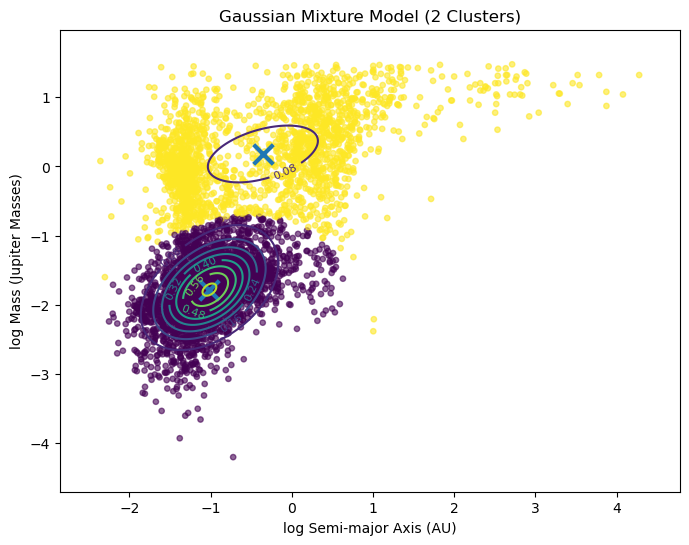

In [9]:
plt.figure(figsize=(8,6))

xgrid = np.linspace(x.min()-0.5, x.max()+0.5, 300)
ygrid = np.linspace(y.min()-0.5, y.max()+0.5, 300)

X, Y = np.meshgrid(xgrid, ygrid)

grid_points = np.vstack([X.ravel(), Y.ravel()]).T

# Total GMM density
Z = np.exp(gmm.score_samples(grid_points))
Z = Z.reshape(X.shape)

# Density contours
contours = plt.contour(
    X,
    Y,
    Z,
    levels=8
)

plt.clabel(contours, inline=True, fontsize=8)



plt.scatter(
    x,
    y,
    c=labels,
    s=15,
    alpha=0.6
)

# Cluster centers
plt.scatter(
    means[:,0],
    means[:,1],
    marker='x',
    s=200,
    linewidths=3
)


plt.xlabel('log Semi-major Axis (AU)')
plt.ylabel('log Mass (Jupiter Masses)')

plt.title('Gaussian Mixture Model (2 Clusters)')

plt.show()

¡Podemos probar con muchos clusters!

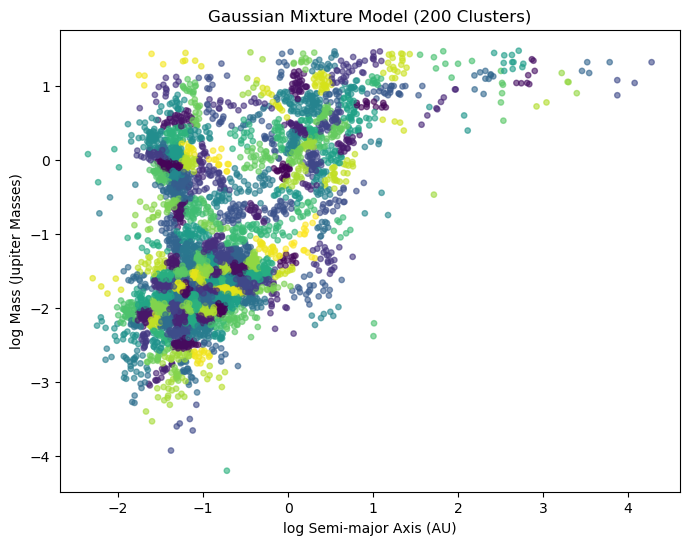

In [10]:
gmm = GaussianMixture(
    n_components=200,
    covariance_type='full',
    random_state=42
)

gmm.fit(data) # fit the data
labels = gmm.predict(data) # assign data to a cluster
means = gmm.means_ # cluster center


plt.figure(figsize=(8,6))

# Scatter colored by cluster
plt.scatter(
    x,
    y,
    c=labels,
    s=15,
    alpha=0.6
)


plt.xlabel('log Semi-major Axis (AU)')
plt.ylabel('log Mass (Jupiter Masses)')

plt.title('Gaussian Mixture Model (200 Clusters)')

plt.show()

## Information Criteria

- Métricas estadísticas utilizadas para comparar modelos.

- Evalúan calidad del ajuste vs. complejidad del modelo.

- Penalizan modelos con demasiados parámetros para evitar sobreajuste.

- Se utilizan para:
  - selección de modelos,
  - elegir número de componentes,
  - comparar diferentes configuraciones.

### Criterios comunes

#### AIC — Akaike Information Criterion
- Favorece buen ajuste predictivo.
- Penalización moderada por complejidad.

#### BIC — Bayesian Information Criterion
- Penaliza más fuertemente modelos complejos.
- Tiende a favorecer modelos más simples.

### Interpretación

- Valores menores indican modelos preferibles.
- Se comparan únicamente entre modelos ajustados al mismo conjunto de datos, por lo tanto no son criterios absolutos sino relativos.

$$\text{AIC} = 2k - 2\ln(L), $$
$$\text{BIC} = k \ln(n) - 2\ln(L)
$$

Donde:

- $k$: Número de parámetros libres del modelo
- $n$: Número de puntos de datos.
- $L$: Valor maximizado de la verosimilitud (*likelihood*) del modelo.

Best number of clusters according to BIC: 9


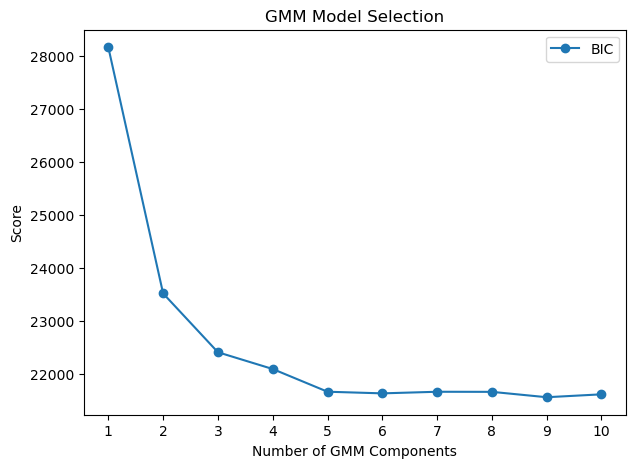

,n_components,9
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [11]:
n_components_range = range(1, 11)

bics = []

for n in n_components_range:

    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(data)

    bics.append(gmm.bic(data))


best_n = n_components_range[np.argmin(bics)]

print(f"Best number of clusters according to BIC: {best_n}")


plt.figure(figsize=(7,5))

plt.plot(n_components_range, bics, marker='o', label='BIC')

plt.xlabel('Number of GMM Components')
plt.ylabel('Score')

plt.xticks(list(n_components_range))

plt.legend()

plt.title('GMM Model Selection')

plt.show()


best_gmm = GaussianMixture(
    n_components=best_n,
    covariance_type='full',
    random_state=42
)

best_gmm.fit(data)


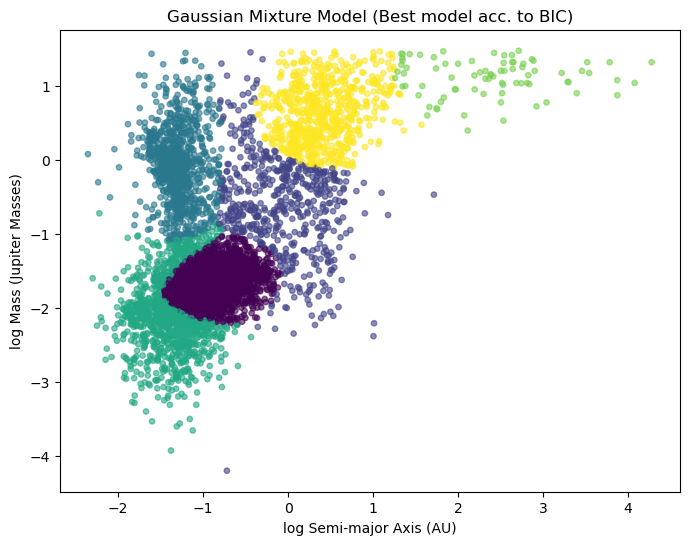

In [12]:

gmm = GaussianMixture(
    n_components=6,
    covariance_type='full',
    random_state=42
)

gmm.fit(data) # fit the data
labels = gmm.predict(data) # assign data to a cluster
means = gmm.means_ # cluster center


plt.figure(figsize=(8,6))

# Scatter colored by cluster
plt.scatter(
    x,
    y,
    c=labels,
    s=15,
    alpha=0.6
)


plt.xlabel('log Semi-major Axis (AU)')
plt.ylabel('log Mass (Jupiter Masses)')

plt.title('Gaussian Mixture Model (Best model acc. to BIC)')

plt.show()

### Agrupamiento por `k-means`

- Algoritmo de clustering no supervisado según similitud o distancia.

- Cada grupo se representa mediante un centroide.

- Busca minimizar la distancia entre los puntos y el centroide de su grupo.

#### Algoritmo básico

1. Inicializar \(k\) centroides.
2. Asignar cada punto al centroide más cercano.
3. Recalcular centroides usando los puntos asignados.
4. Repetir hasta convergencia.

#### Características

- Simple y computacionalmente eficiente.
- Funciona mejor para grupos aproximadamente esféricos y bien separados.
- A diferencia de GMM, K-means impone clusters aproximadamente esféricos y asignaciones rígidas, mientras que GMM permite distribuciones elípticas y asignaciones probabilísticas más flexibles y estadísticamente/físicamente interpretables.

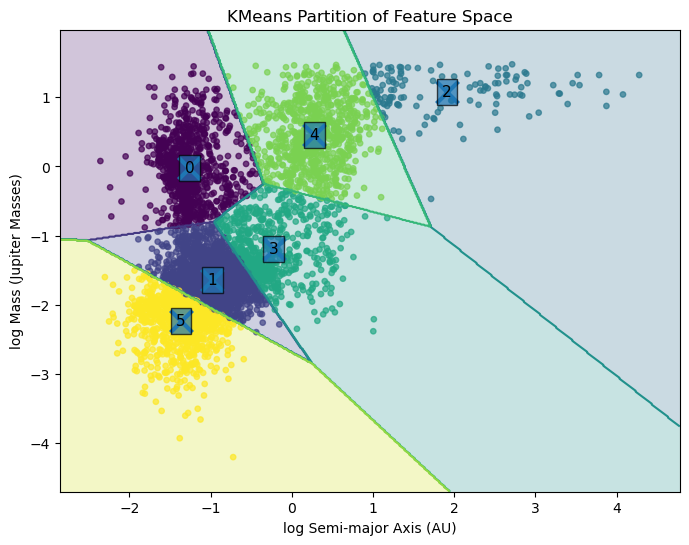

In [13]:
from sklearn.cluster import KMeans

x = np.array(log_semimajor_axis)
y = np.array(log_mass)

data = np.vstack([x, y]).T

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=20
)

kmeans.fit(data)

labels = kmeans.labels_
means = kmeans.cluster_centers_


x_min, x_max = x.min()-0.5, x.max()+0.5
y_min, y_max = y.min()-0.5, y.max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predict cluster for every grid point
Z = kmeans.predict(grid)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.25
)

plt.contour(
    xx,
    yy,
    Z,
    levels=np.arange(-0.5, 6, 1),
    linewidths=1.5
)

plt.scatter(
    x,
    y,
    c=labels,
    s=15,
    alpha=0.7
)

plt.scatter(
    means[:,0],
    means[:,1],
    marker='x',
    s=250,
    linewidths=3
)

for i, (mx, my) in enumerate(means):

    plt.text(
        mx,
        my,
        f'{i}',
        fontsize=11,
        ha='center',
        va='center',
        bbox=dict(alpha=0.7)
    )

plt.xlabel('log Semi-major Axis (AU)')
plt.ylabel('log Mass (Jupiter Masses)')

plt.title('KMeans Partition of Feature Space')

plt.show()

## Distribución de Exoplanetas: Principal Component Analysis (PCA)

- Método de reducción de dimensionalidad basado en álgebra lineal.

- Busca nuevas variables llamadas componentes principales.

- Cada componente principal representa una dirección de máxima varianza en los datos.

- Los componentes:
  - son ortogonales entre sí,
  - están ordenados según la cantidad de varianza explicada.

- Permite representar datos complejos usando menos dimensiones conservando gran parte de la información.

- Los datos se proyectan sobre nuevas direcciones que contienen la mayor variación posible.

![Project Logo](imagenes/pca.jpeg)

### Problema: Densidad vs. Radio

Vamos a analizar sub-tendencias de densidad vs. radio para exoplanetas. En principio hay planetas rocosos con alta densidad y planetas gaseosos con baja densidad. Sin embargo, aprovechemos lo que ya aprendimos para encontrar sub-poblaciones sin suposiciones previas.


In [14]:
columns = [
    'pl_rade',
    'pl_dens'
]

table2 = NasaExoplanetArchive.query_criteria(
    table='ps',
    select=','.join(columns),
    where='pl_rade is not null and pl_dens is not null and default_flag = 1',
    order='pl_name ASC' # Order by name y
)

print(f"Found {len(table2)} exoplanets with reported radius and density.")

radius_value=table2['pl_rade'].value
dens_value=table2['pl_dens'].value

Found 1195 exoplanets with reported radius and density.


In [15]:
valid_indices = (radius_value > 0) & (dens_value > 0)
radius_values = radius_value[valid_indices]
dens_values = dens_value[valid_indices]

log_dens=np.log10(dens_values)
log_radius=np.log10(radius_values)

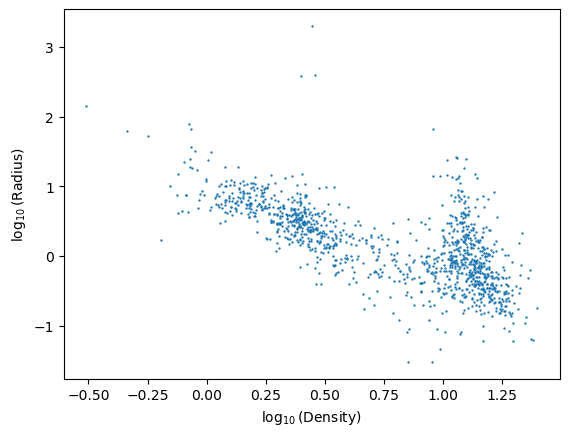

In [16]:
plt.scatter(log_radius,log_dens,s=0.5)
plt.xlabel(r'$\log_{10}(\mathrm{Density})$')
plt.ylabel(r'$\log_{10}(\mathrm{Radius})$')

plt.show()

Best number of components (BIC): 5


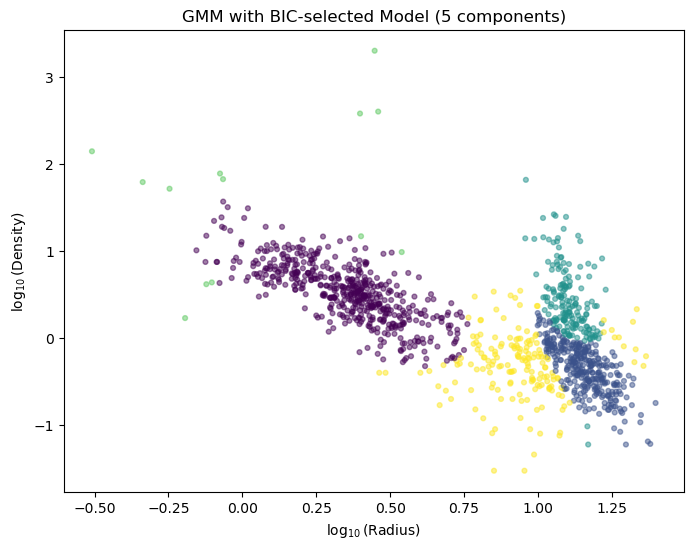

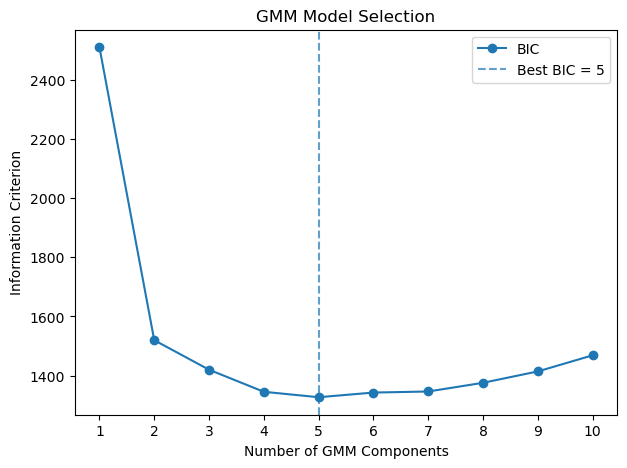

In [17]:
data = np.vstack([log_radius,log_dens]).T


x = data[:,0]
y = data[:,1]


n_components_range = range(1, 11)

bics = []
models = []

for n in n_components_range:

    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )

    gmm.fit(data)

    bics.append(gmm.bic(data))
    models.append(gmm)

best_idx = np.argmin(bics)
best_n = list(n_components_range)[best_idx]
best_gmm = models[best_idx]

print(f"Best number of components (BIC): {best_n}")

labels = best_gmm.predict(data)

plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    c=labels,
    s=12,
    alpha=0.5
)

means = best_gmm.means_

plt.ylabel(r'$\log_{10}(\mathrm{Density})$')
plt.xlabel(r'$\log_{10}(\mathrm{Radius})$')

plt.title(f'GMM with BIC-selected Model ({best_n} components)')

plt.show()

plt.figure(figsize=(7,5))

plt.plot(
    n_components_range,
    bics,
    marker='o',
    label='BIC'
)

plt.axvline(
    best_n,
    linestyle='--',
    alpha=0.7,
    label=f'Best BIC = {best_n}'
)

plt.legend()

plt.xlabel('Number of GMM Components')
plt.ylabel('Information Criterion')

plt.xticks(list(n_components_range))

plt.title('GMM Model Selection')

plt.show()



Best number of components (BIC): 5


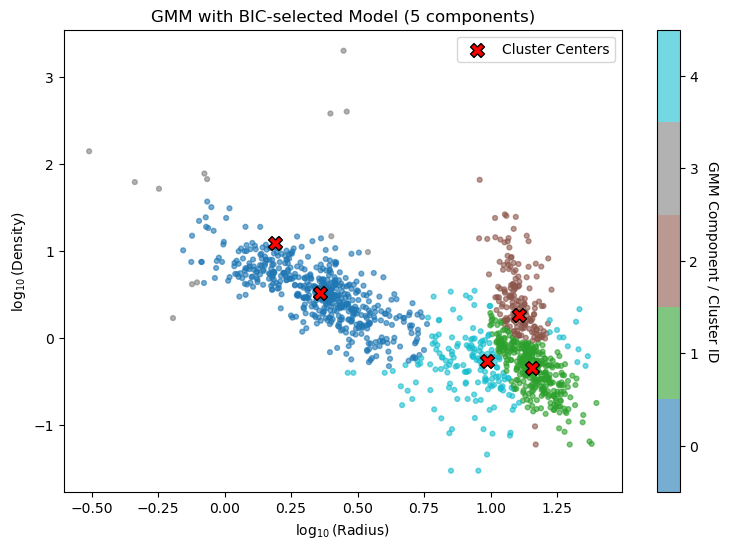

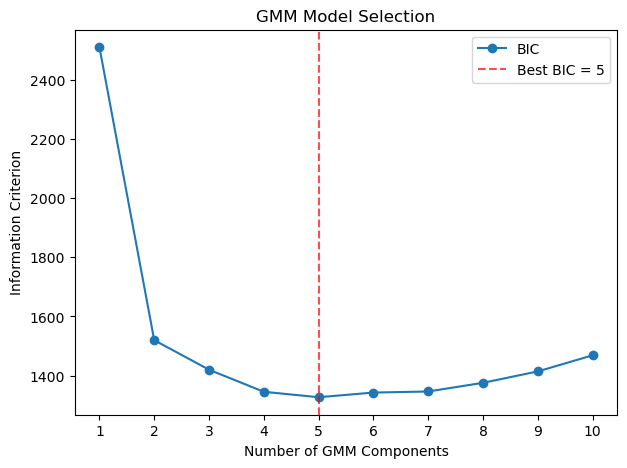

In [18]:
data = np.vstack([log_radius, log_dens]).T
x = data[:, 0]
y = data[:, 1]

n_components_range = range(1, 11)
bics = []
models = []

for n in n_components_range:
    gmm = GaussianMixture(
        n_components=n,
        covariance_type='full',
        random_state=42
    )
    gmm.fit(data)
    bics.append(gmm.bic(data))
    models.append(gmm)

best_idx = np.argmin(bics)
best_n = list(n_components_range)[best_idx]
best_gmm = models[best_idx]

print(f"Best number of components (BIC): {best_n}")

labels = best_gmm.predict(data)

plt.figure(figsize=(9, 6))

# Define a qualitative/discrete colormap based on the best number of components
cmap = plt.get_cmap('tab10', best_n)

scatter = plt.scatter(
    x,
    y,
    c=labels,
    cmap=cmap,          # Apply the discrete colormap
    s=12,
    alpha=0.6,
    vmin=-0.5,
    vmax=best_n - 0.5
)

cbar = plt.colorbar(scatter, ticks=range(best_n))
cbar.set_label('GMM Component / Cluster ID', rotation=270, labelpad=15)

means = best_gmm.means_
plt.scatter(
    means[:, 0],
    means[:, 1],
    c='red',
    marker='X',
    s=100,
    edgecolors='black',
    label='Cluster Centers'
)
plt.legend()

plt.ylabel(r'$\log_{10}(\mathrm{Density})$')
plt.xlabel(r'$\log_{10}(\mathrm{Radius})$')
plt.title(f'GMM with BIC-selected Model ({best_n} components)')
plt.show()



plt.figure(figsize=(7, 5))
plt.plot(
    n_components_range,
    bics,
    marker='o',
    label='BIC'
)
plt.axvline(
    best_n,
    linestyle='--',
    alpha=0.7,
    color='red',
    label=f'Best BIC = {best_n}'
)
plt.legend()
plt.xlabel('Number of GMM Components')
plt.ylabel('Information Criterion')
plt.xticks(list(n_components_range))
plt.title('GMM Model Selection')
plt.show()

/var/folders/2y/t3gprvl52s75ccs56z7ml0s80000gn/T/ipykernel_24003/4255502184.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


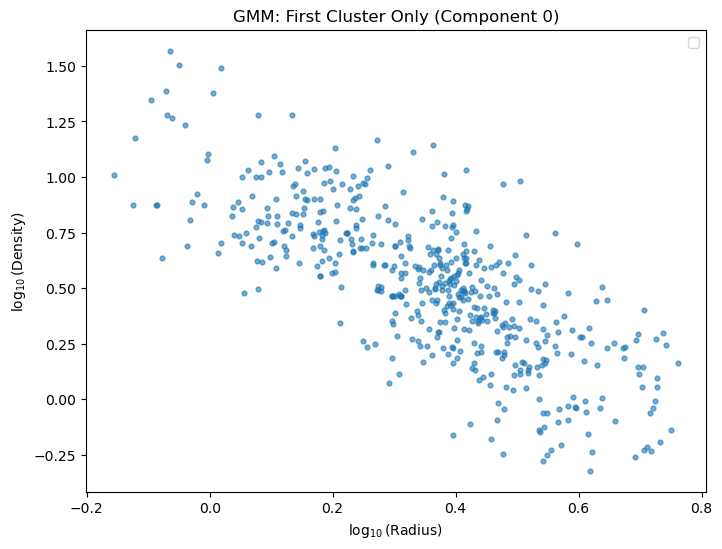

In [19]:
first_cluster_mask = (labels == 0)

x_sub=x[first_cluster_mask]
y_sub=y[first_cluster_mask]


plt.figure(figsize=(8, 6))

plt.scatter(
    x_sub,y_sub,
    c='tab:blue',
    s=12,
    alpha=0.6
)

means = best_gmm.means_


plt.ylabel(r'$\log_{10}(\mathrm{Density})$')
plt.xlabel(r'$\log_{10}(\mathrm{Radius})$')
plt.title('GMM: First Cluster Only (Component 0)')
plt.legend()

plt.show()

## Preprocesamiento

- Conjunto de transformaciones aplicadas a los datos antes del análisis o entrenamiento.

- Busca mejorar:
  - calidad de los datos,
  - estabilidad numérica,
  - desempeño del modelo.

- Puede incluir:
  - limpieza de datos,
  - normalización,
  - estandarización,
  - manejo de valores faltantes.

## Estandarización

- Transformación que centra y escala las variables.

- Cada variable se transforma para tener promedio 0 y desviación estándar 1.

- Importante cuando distintas variables tienen escalas muy diferentes.

- Muy utilizada en:
  - PCA,
  - K-means,
  - SVM,
  - redes neuronales.

Explained variance ratio:
[0.87734087 0.12265913]

Principal components:
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


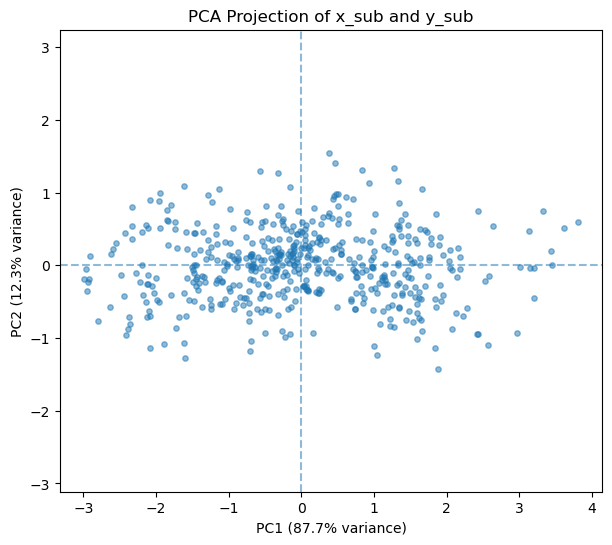

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

x = np.array(x_sub)
y = np.array(y_sub)

data = np.vstack([x, y]).T

mask = np.isfinite(data).all(axis=1)
data = data[mask]


scaler = StandardScaler()

data_scaled = scaler.fit_transform(data)

pca = PCA(n_components=2)

pca_data = pca.fit_transform(data_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("\nPrincipal components:")
print(pca.components_)

plt.figure(figsize=(7,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    s=15,
    alpha=0.5
)

plt.axhline(0, linestyle='--', alpha=0.5)
plt.axvline(0, linestyle='--', alpha=0.5)

plt.xlabel(
    f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)'
)

plt.ylabel(
    f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)'
)

plt.title('PCA Projection of x_sub and y_sub')

plt.axis('equal')

plt.show()

**Ejercicio**: Revise los demás grupos y reporte para cuáles el PCA muestra que el primer componente cubre aproximadamente el 90% de varianza. ¿Cómo se interpretaría astrofísicamente cada uno de estos casos?

**Ejercicio**: Use la columna `st_met` para buscar la relación entre la masa y la metalicidad (estrellas con más metalicidad tienen más probabilidad de tener planetas gigantes, es decir con más de 10 masas terrestres). Puede usar KDE, GMM, PCA, etc.

**Tutorial** con ejemplos de uso de PCA, recomiendo ver el ejemplo sobre reconocimiento de dígitos escritos a mano: [Enlace](https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html).

**Tutorial** para el uso de PCA con espectros de SDSS: [Enlace](https://ogrisel.github.io/scikit-learn.org/sklearn-tutorial/tutorial/astronomy/dimensionality_reduction.html).

**Ejemplos** de algoritmos de reducción de dimensionalidad no lineales incluyendo Locally Linear Embedding: [Enlace](https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html).

## Apéndice: La Matemática del Análisis de Componentes Principales (PCA)

PCA es un algoritmo basado en álgebra lineal en el que las componentes principales se identifican con los eigenvectores de la matriz de covarianza asociada a los datos.

Empecemos con un conjunto de datos con $$n$$ observaciones y $$p$$ variables, organizado en una matriz (estandarizada)

$$
X \in \mathbb{R}^{n \times p}
$$

PCA busca nuevas direcciones ortogonales en el espacio de variables a lo largo de las cuales la varianza de los datos es máxima.

---

### Matriz de Covarianza

La matriz de covarianza es

$$
C = \frac{1}{n-1} X^T X
$$

y mide cómo varían conjuntamente las variables.

---

### Eigenvectores y Eigenvalores

PCA resuelve el problema de eigenvalores

$$
C \mathbf{v} = \lambda \mathbf{v}
$$

El eigenvector permanece invariante bajo la transformación dada por la matriz de covarianza, excepto por un factor de escala.

El eigenvalor indica cuánta varianza existe a lo largo de esa dirección.

---

### Componentes Principales

Los eigenvectores de la matriz de covarianza corresponden a las **componentes principales**.

- Primera componente principal:
  dirección de máxima varianza.

- Segunda componente principal:
  dirección ortogonal a la primera con la siguiente mayor varianza.

- etc.

Los eigenvectores se ordenan de acuerdo con sus eigenvalores en orden decreciente.

---

### Proyección

Para reducir dimensionalidad, los datos se proyectan sobre los primeros $$k$$ eigenvectores:

$$
Z = X W
$$

donde

$$
W =
\begin{bmatrix}
| & | & & | \\
\mathbf{v}_1 & \mathbf{v}_2 & \cdots & \mathbf{v}_k \\
| & | & & |
\end{bmatrix}
$$

Entonces,

$$
Z \in \mathbb{R}^{n \times k}
$$

es la representación de baja dimensionalidad.

---

### Interpretación Geométrica

PCA rota el sistema de coordenadas de manera que:

- el primer eje apunta en la dirección de mayor dispersión de los datos,
- el segundo eje apunta en la siguiente dirección de mayor dispersión,
- etc.

Esto produce la representación de menor dimensionalidad que preserva la mayor cantidad posible de varianza en el sentido de mínimos cuadrados.

---

### Varianza Explicada

La fracción de varianza explicada por la componente $$i$$ es

$$
\frac{\lambda_i}{\sum_j \lambda_j}
$$

Eigenvalores grandes corresponden a estructuras importantes en los datos.